In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [15]:
df = pd.read_csv("q2_customers.csv")

features = df[['age', 'annual_spend', 'visits_per_month', 'basket_size', 'days_since_last_visit', 'num_categories_purchased']]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

Scaling ensures all features contribute equally to distance calculatiion in K-means, preventing bias due to different feature magnitude

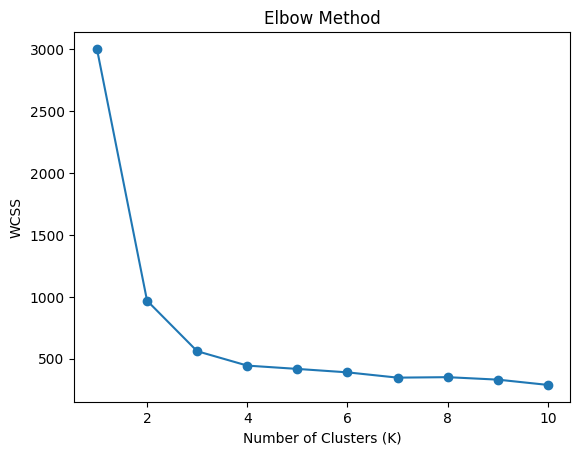

In [7]:
from sklearn.cluster import KMeans

wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

"The elbow occurs at K = 3, where WCSS reduction slows, indicating optimal clustering."

In [20]:
features = df[['age', 'annual_spend', 'visits_per_month', 'basket_size', 'days_since_last_visit', 'num_categories_purchased']]


kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_data)


centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=features.columns
)
print(centroids)

         age  annual_spend  visits_per_month  basket_size  \
0  24.676471  14847.370588         14.341176   558.970588   
1  56.769697  89413.333333          2.527273  5530.545455   
2  40.387879  43340.733333          8.193939  2021.684848   

   days_since_last_visit  num_categories_purchased  
0               9.076471                  2.111765  
1             105.357576                  7.515152  
2              35.187879                  4.424242  


"Cluster 0 represents young customers with frequent visits but low spending."

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

df['PC1'] = pca_data[:,0]
df['PC2'] = pca_data[:,1]

print(pca.explained_variance_ratio_)

loadings = pd.DataFrame(
    pca.components_,
    columns =features.columns,
    index=['PC1', 'PC2']
)

print(loadings)



[0.83560354 0.05568764]
          age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


If PC1 has high values for: annual_spend and basket_size

Then:- "PC1 represents customer spending behavior."

If PC2 has high values for:
visits_per_month and days_sine_last_visit

Then:- "PC2 represents customer engagement or acticity level."

In [33]:
print(df.columns)

Index(['age', 'annual_spend', 'visits_per_month', 'basket_size',
       'days_since_last_visit', 'num_categories_purchased', 'cluster', 'pca1',
       'pca2', 'PC1', 'PC2'],
      dtype='object')


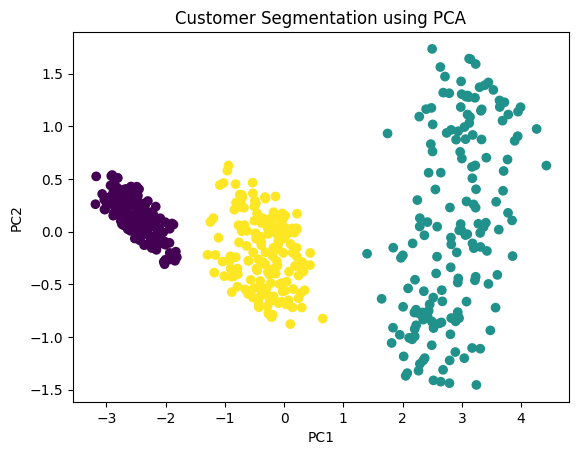

In [34]:
plt.scatter(df['PC1'], df['PC2'], c=df['cluster'])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentation using PCA")
plt.show()


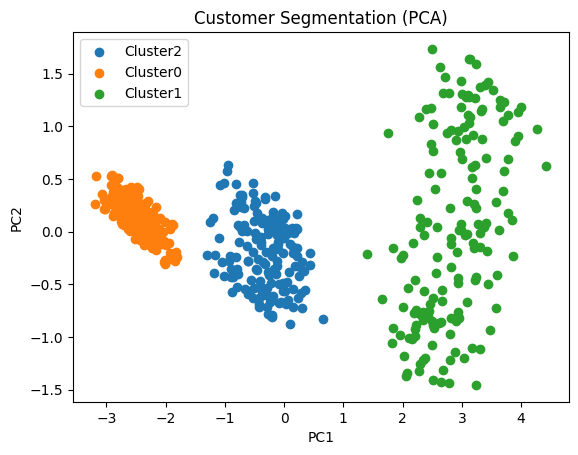

In [35]:
plt.figure()

for cluster in df['cluster'].unique():
    subset = df[df['cluster'] == cluster]
    plt.scatter(subset['PC1'], subset['PC2'], label=f'Cluster{cluster}')

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentation (PCA)")
plt.legend()
plt.show()

Pca Interpretation: "PCA reduced the dataset to two components while preserving most variance.
PC1 represents spending behavior, while PC2 represents customer activity."

Visualization Interpretation: "The scatter plot shows clear separation between customer segments, indication effective clustering using K-Means
